# 01 — Feature Engineering propre train / test

Objectif :

- faire l'EDA **uniquement sur le train** ;
- définir des transformations reproductibles ;
- appliquer exactement le même feature engineering au train et au test ;
- sauvegarder deux fichiers séparés :
  - `train_fe.parquet`
  - `test_fe.parquet`

Règle importante : le test ne sert pas à décider les règles. On lui applique uniquement les règles définies à partir du train ou des règles déterministes métier.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src.config import PATHS
from src.data import load_csv, save_parquet
# from src.features import basic_cleaning, add_simple_features

RANDOM_STATE = 42
TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"

print("Data raw:", PATHS.data_raw)
print("Data processed:", PATHS.data_processed)

Data raw: C:\projects\openclassrooms_DS\P7\ds_project_7_credit_scoring\data\raw
Data processed: C:\projects\openclassrooms_DS\P7\ds_project_7_credit_scoring\data\processed


## 1) Charger les fichiers bruts

On charge séparément le train et le test. Le train contient `TARGET`, le test ne doit normalement pas contenir `TARGET`.

In [2]:
train_path_full = PATHS.data_raw / "application_train.csv"
train_path_sample = PATHS.data_raw / "application_train_head.csv"

test_path_full = PATHS.data_raw / "application_test.csv"
test_path_sample = PATHS.data_raw / "application_test_head.csv"

train_path = train_path_full if train_path_full.exists() else train_path_sample
test_path = test_path_full if test_path_full.exists() else test_path_sample

app_train_raw = load_csv(train_path)
app_test_raw = load_csv(test_path)

print("Train raw shape:", app_train_raw.shape)
print("Test raw shape :", app_test_raw.shape)

assert TARGET_COL in app_train_raw.columns, f"{TARGET_COL} doit être présent dans le train"
if TARGET_COL in app_test_raw.columns:
    print(f"Attention : {TARGET_COL} est présent dans le test. Il sera ignoré côté features test si besoin.")

app_train_raw.head()

Train raw shape: (99999, 122)
Test raw shape : (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2) EDA — train uniquement

Tout ce qui sert à comprendre les distributions, les corrélations avec la cible ou à prendre des décisions de nettoyage se fait sur le train uniquement.

In [3]:
# Comptage de la cible — équivalent à df['TARGET'].value_counts()
app_train_raw[TARGET_COL].value_counts()

TARGET
0    91906
1     8093
Name: count, dtype: int64

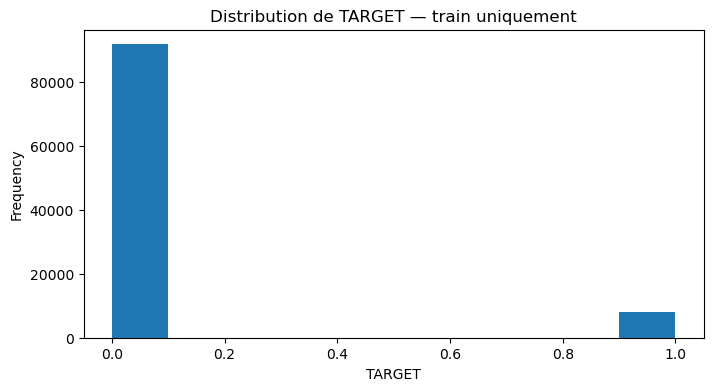

In [4]:
# Distribution de la cible — équivalent au graphique initial
plt.figure(figsize=(8, 4))
app_train_raw[TARGET_COL].astype(int).plot.hist()
plt.title("Distribution de TARGET — train uniquement")
plt.xlabel("TARGET")
plt.show()

In [5]:
# Types de variables — équivalent à df.dtypes.value_counts()
app_train_raw.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [6]:
# Nombre de modalités par variable catégorielle — train uniquement
app_train_raw.select_dtypes("object").apply(pd.Series.nunique, axis=0).sort_values(ascending=False)

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WEEKDAY_APPR_PROCESS_START     7
WALLSMATERIAL_MODE             7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
CODE_GENDER                    3
HOUSETYPE_MODE                 3
NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64

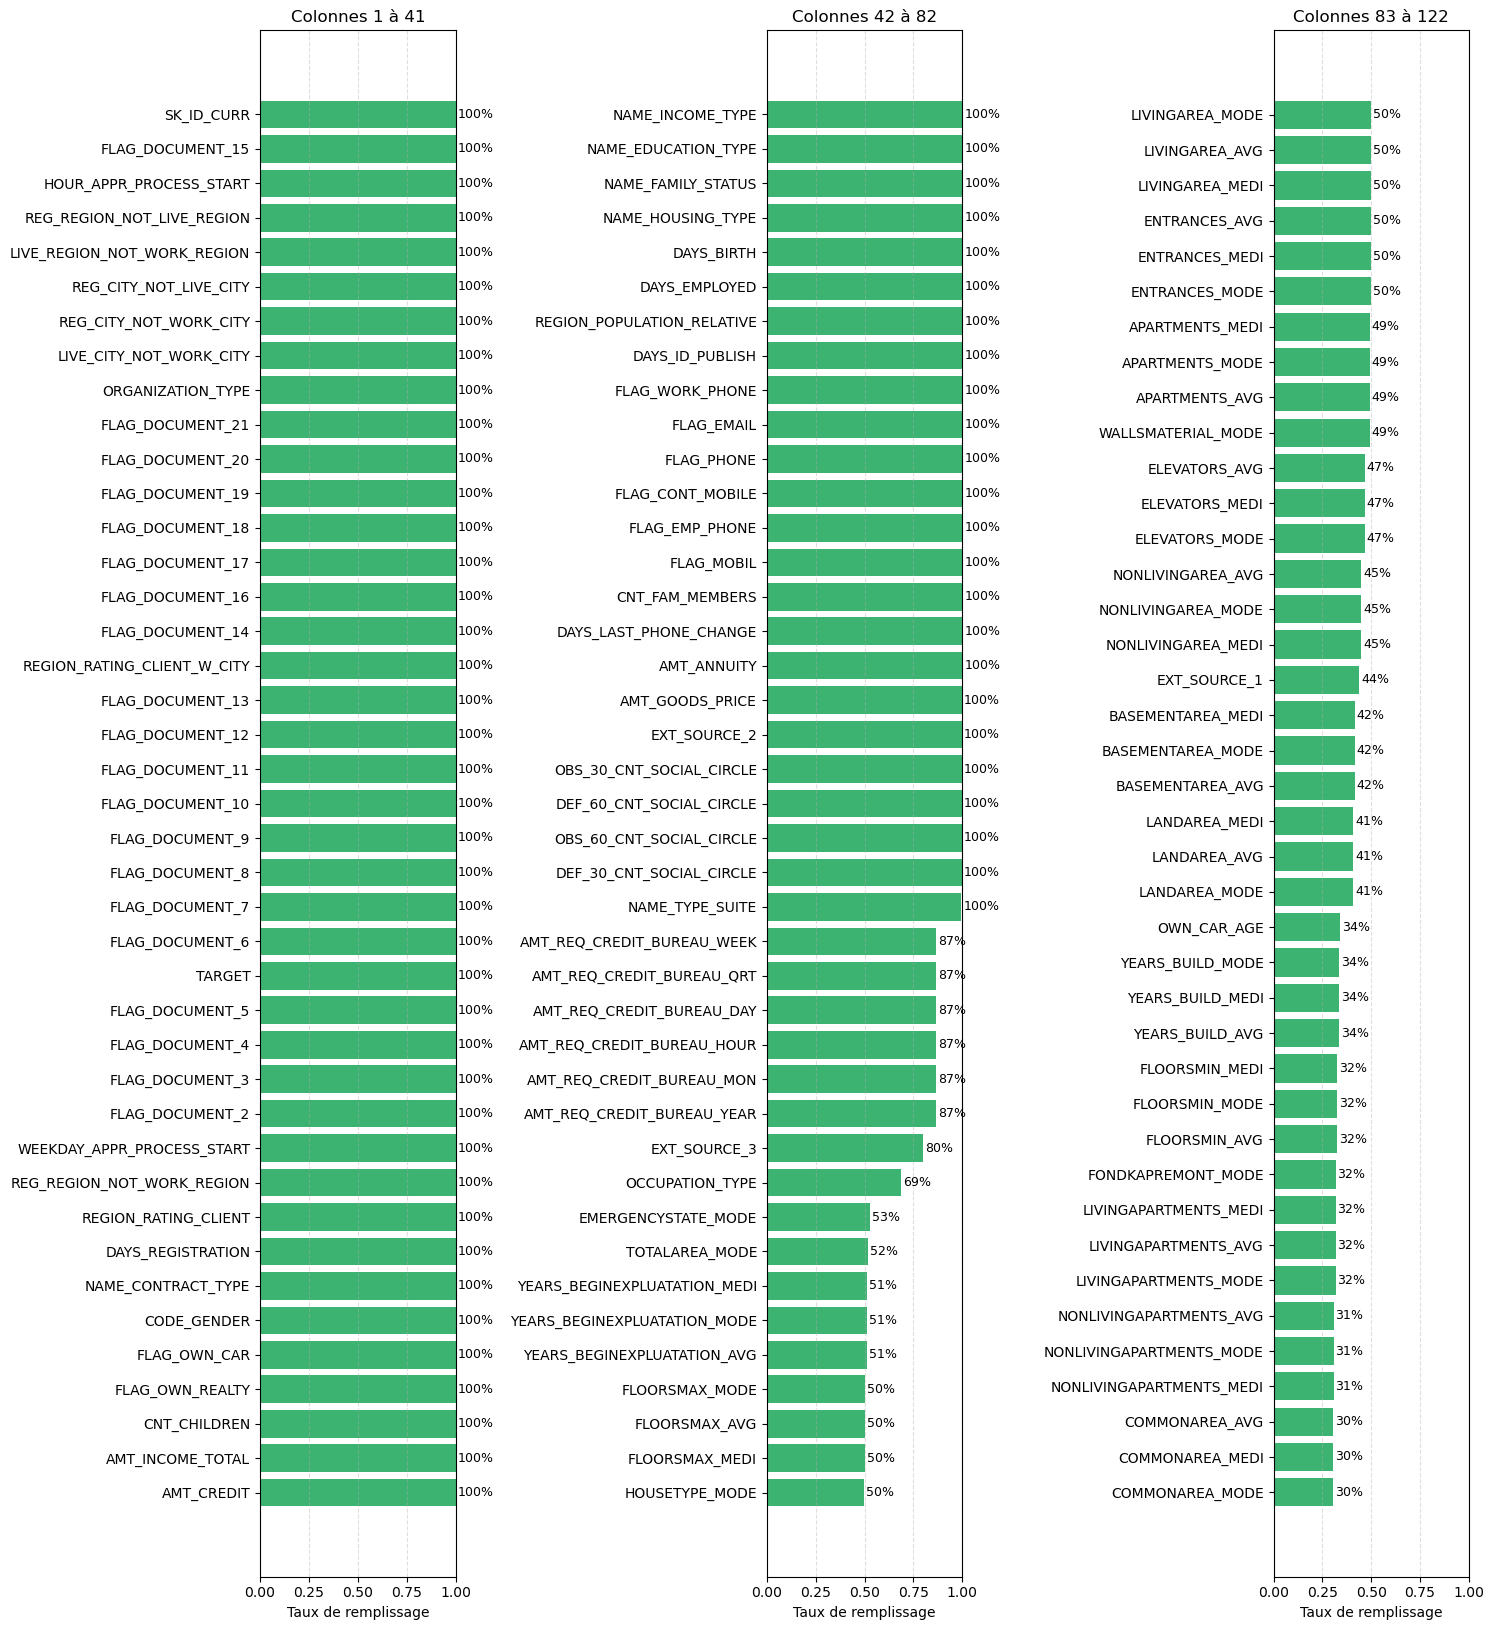

In [7]:
# Taux de remplissage des variables
import utils.utils as utils

df = app_train_raw
utils.plot_fill_rate_side_by_side(df, 3, 0)

Top 6 corrélations négatives :
EXT_SOURCE_3     -0.178742
EXT_SOURCE_2     -0.161656
EXT_SOURCE_1     -0.153105
DAYS_BIRTH       -0.076839
FLOORSMAX_AVG    -0.044961
FLOORSMAX_MEDI   -0.044462
Name: TARGET, dtype: float64

Top 6 corrélations positives :
DAYS_LAST_PHONE_CHANGE         0.053015
REGION_RATING_CLIENT           0.061597
REGION_RATING_CLIENT_W_CITY    0.062815
RATIO_EMPLOYED_BIRTH           0.065750
DAYS_EMPLOYED                  0.072738
TARGET                         1.000000
Name: TARGET, dtype: float64


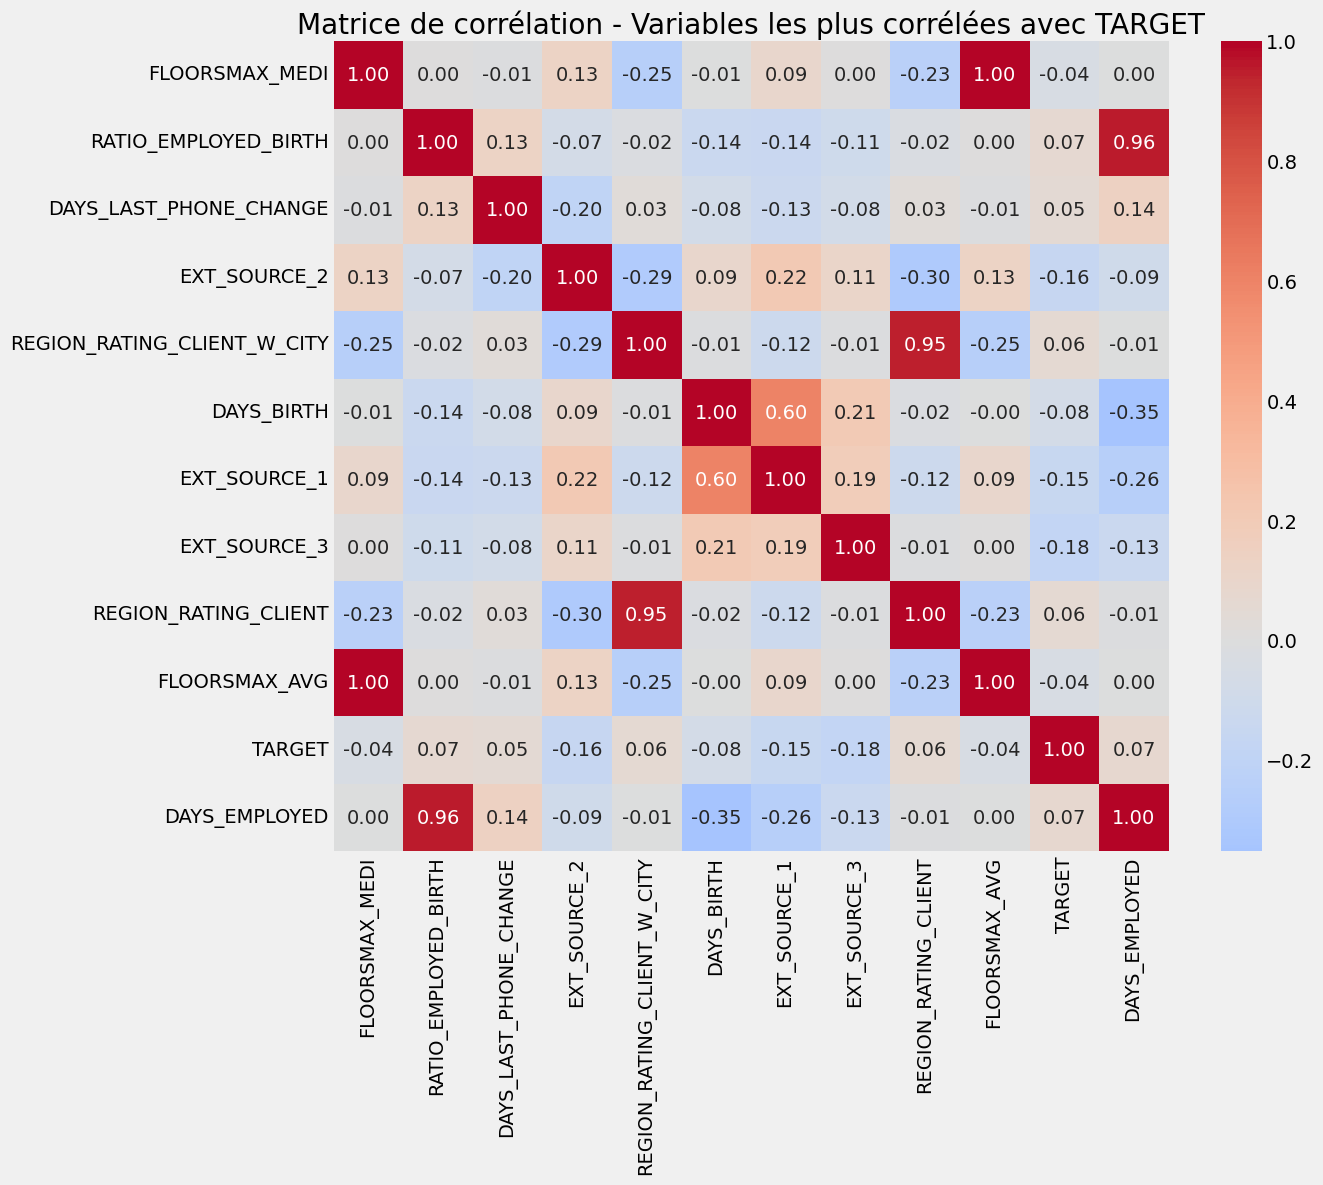

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = app_train_raw
top_n = 6

# ============================================================
# 1. Corrélations avec la target
# ============================================================

# Garder uniquement les colonnes numériques
numeric_df = df.select_dtypes(include=["number"])

# Corrélation avec TARGET
correlations = numeric_df.corr()["TARGET"].sort_values()

# ============================================================
# 2. Top top_n corrélations négatives
# ============================================================

top_negative = correlations.head(top_n)

print(f"Top {top_n} corrélations négatives :")
print(top_negative)

# ============================================================
# 3. Top top_n corrélations positives
# ============================================================

top_positive = correlations.tail(top_n)

print(f"\nTop {top_n} corrélations positives :")
print(top_positive)

# ============================================================
# 4. Heatmap des variables les plus corrélées
# ============================================================

# Fusionner les colonnes les plus positives et négatives
top_features = list(top_negative.index) + list(top_positive.index)

# Supprimer doublons éventuels
top_features = list(set(top_features))

# Ajouter TARGET
if "TARGET" not in top_features:
    top_features.append("TARGET")

# Sous-dataframe
corr_df = numeric_df[top_features]

# Matrice de corrélation
corr_matrix = corr_df.corr()

# ============================================================
# 5. Affichage heatmap
# ============================================================

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation - Variables les plus corrélées avec TARGET")
plt.show()

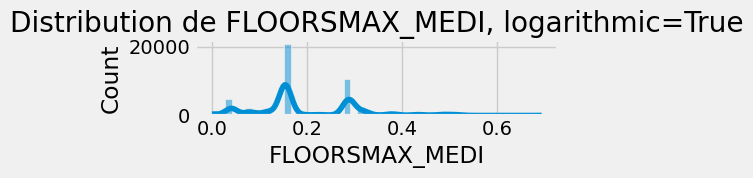

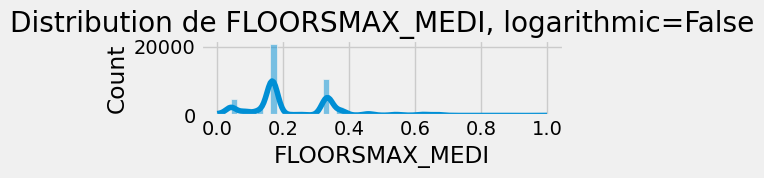

C:\apps\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\apps\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


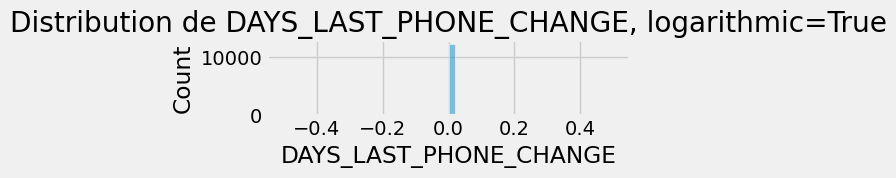

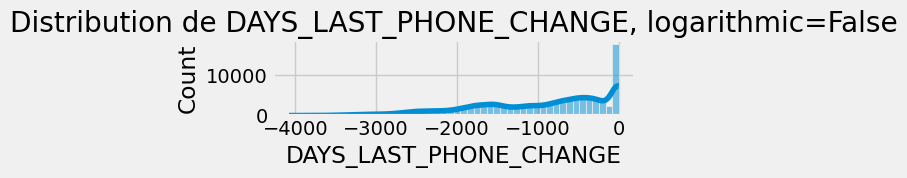

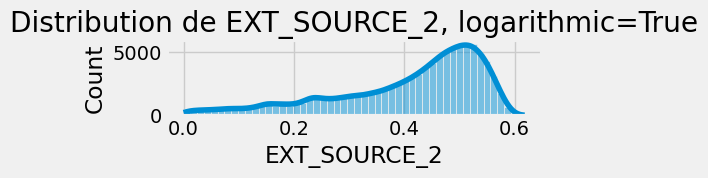

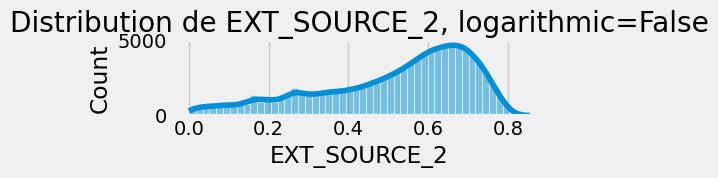

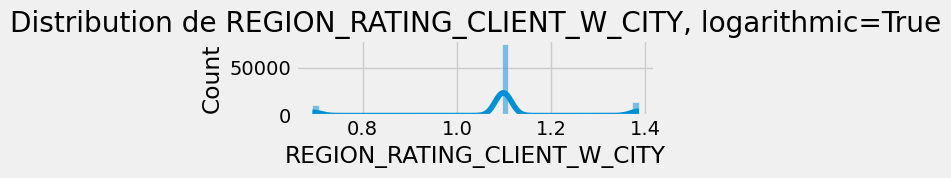

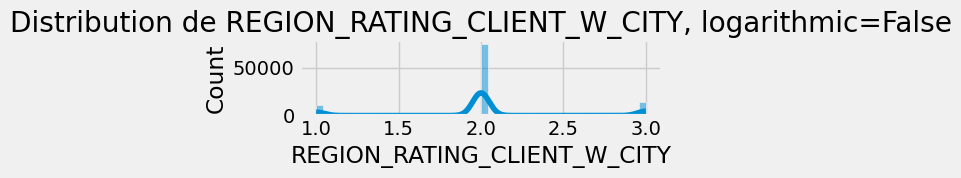

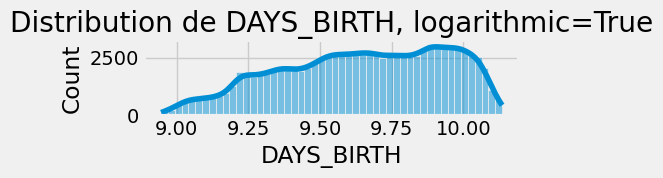

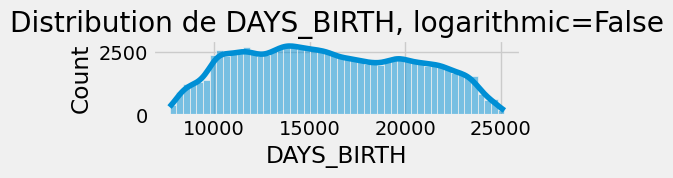

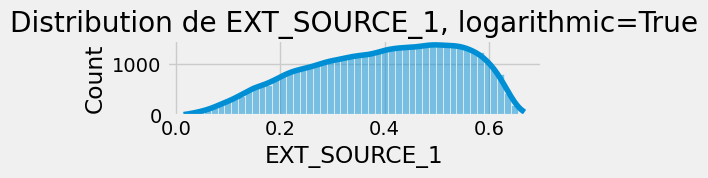

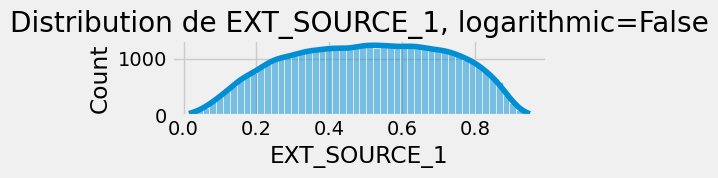

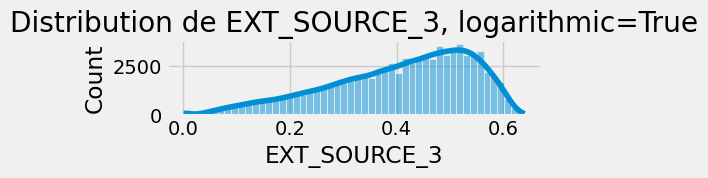

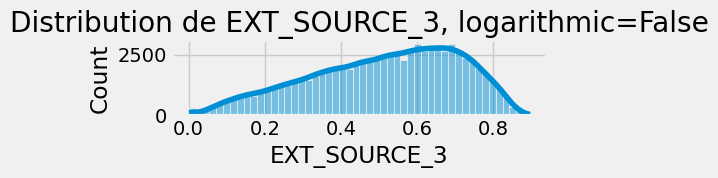

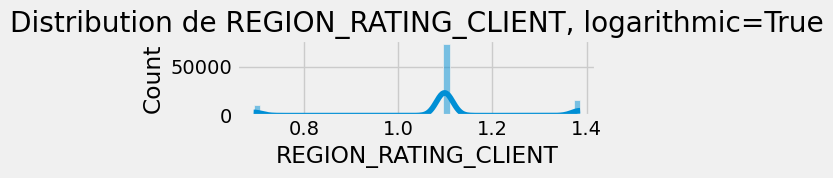

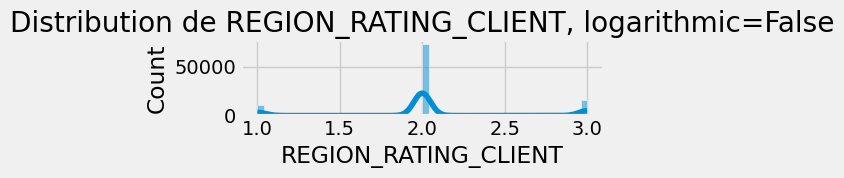

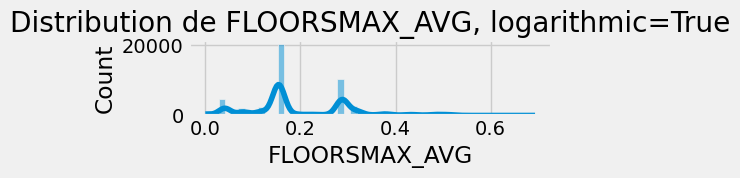

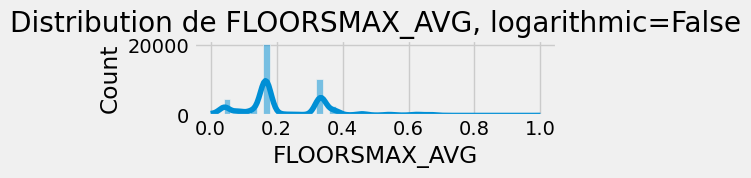

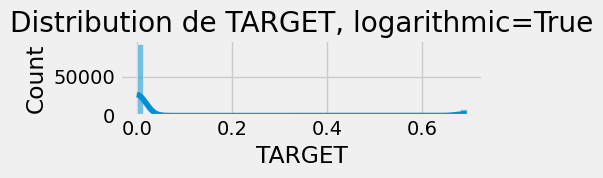

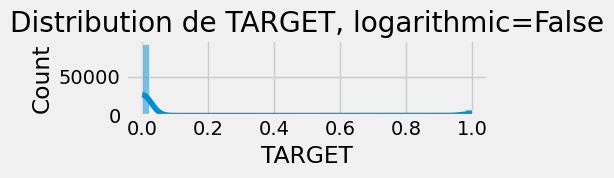

In [29]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # monte d'un niveau (../)
import utils.utils_p4 as utils_p4

for col in corr_df.columns:
    utils_p4.display_distribution(df, col, True)
    utils_p4.display_distribution(df, col, False)

In [9]:

# Description de l'âge en années — équivalent à (df['DAYS_BIRTH'] / -365).describe()
if "DAYS_BIRTH" in app_train_raw.columns:
    display((app_train_raw["DAYS_BIRTH"] / -365).describe())

count    99999.000000
mean        43.908125
std         11.968022
min         21.030137
25%         33.946575
50%         43.128767
75%         53.884932
max         69.043836
Name: DAYS_BIRTH, dtype: float64

In [10]:
# Description de DAYS_EMPLOYED avant traitement de l'anomalie
if "DAYS_EMPLOYED" in app_train_raw.columns:
    display(app_train_raw["DAYS_EMPLOYED"].describe())

count     99999.000000
mean      63292.887289
std      140840.244402
min      -17531.000000
25%       -2758.000000
50%       -1219.000000
75%        -291.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

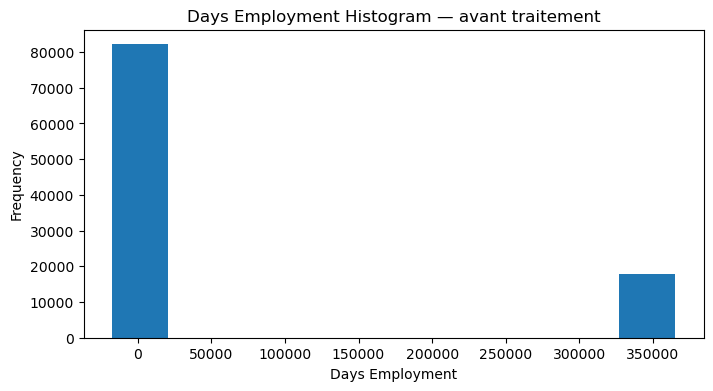

In [11]:
# Histogramme DAYS_EMPLOYED avant remplacement de l'anomalie
if "DAYS_EMPLOYED" in app_train_raw.columns:
    plt.figure(figsize=(8, 4))
    app_train_raw["DAYS_EMPLOYED"].plot.hist(title="Days Employment Histogram — avant traitement")
    plt.xlabel("Days Employment")
    plt.show()

In [12]:
# Analyse de l'anomalie DAYS_EMPLOYED == 365243 — train uniquement
if "DAYS_EMPLOYED" in app_train_raw.columns:
    anom_train = app_train_raw[app_train_raw["DAYS_EMPLOYED"] == 365243]
    non_anom_train = app_train_raw[app_train_raw["DAYS_EMPLOYED"] != 365243]

    print("The non-anomalies default on %0.2f%% of loans" % (100 * non_anom_train[TARGET_COL].mean()))
    print("The anomalies default on %0.2f%% of loans" % (100 * anom_train[TARGET_COL].mean()))
    print("There are %d anomalous days of employment" % len(anom_train))

The non-anomalies default on 8.66% of loans
The anomalies default on 5.50% of loans
There are 17865 anomalous days of employment


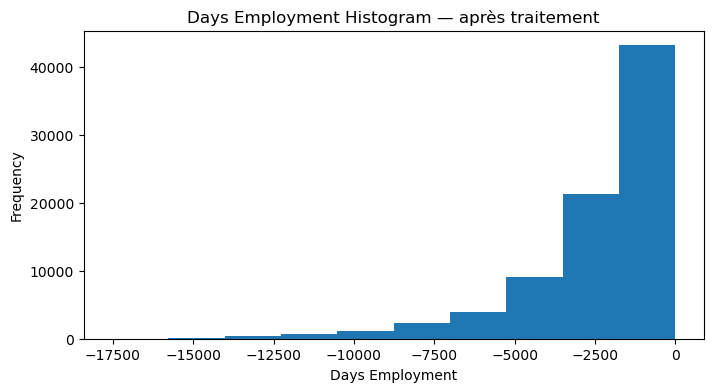

In [13]:
# Histogramme DAYS_EMPLOYED après remplacement de 365243 par NaN
# Important : on travaille sur une copie pour ne pas modifier app_train_raw pendant l'EDA.
if "DAYS_EMPLOYED" in app_train_raw.columns:
    app_train_days_demo = app_train_raw.copy()
    app_train_days_demo["DAYS_EMPLOYED_ANOM"] = app_train_days_demo["DAYS_EMPLOYED"] == 365243
    app_train_days_demo["DAYS_EMPLOYED"] = app_train_days_demo["DAYS_EMPLOYED"].replace(365243, np.nan)

    plt.figure(figsize=(8, 4))
    app_train_days_demo["DAYS_EMPLOYED"].plot.hist(title="Days Employment Histogram — après traitement")
    plt.xlabel("Days Employment")
    plt.show()

In [14]:
# Corrélations avec TARGET — train uniquement
numeric_train = app_train_raw.select_dtypes(include=["int64", "float64", "int32", "float32"])
if TARGET_COL in numeric_train.columns:
    correlations = numeric_train.corr()[TARGET_COL].sort_values()
    print("Most Positive Correlations:\n", correlations.tail(15))
    print("\nMost Negative Correlations:\n", correlations.head(15))

Most Positive Correlations:
 LIVE_CITY_NOT_WORK_CITY        0.032884
DEF_30_CNT_SOCIAL_CIRCLE       0.035462
DEF_60_CNT_SOCIAL_CIRCLE       0.036548
REG_CITY_NOT_LIVE_CITY         0.036816
DAYS_REGISTRATION              0.039269
OWN_CAR_AGE                    0.043349
FLAG_DOCUMENT_3                0.043774
FLAG_EMP_PHONE                 0.044350
REG_CITY_NOT_WORK_CITY         0.048272
DAYS_ID_PUBLISH                0.051792
DAYS_LAST_PHONE_CHANGE         0.053015
REGION_RATING_CLIENT           0.061597
REGION_RATING_CLIENT_W_CITY    0.062815
DAYS_BIRTH                     0.076839
TARGET                         1.000000
Name: TARGET, dtype: float64

Most Negative Correlations:
 EXT_SOURCE_3                 -0.178742
EXT_SOURCE_2                 -0.161656
EXT_SOURCE_1                 -0.153105
FLOORSMAX_AVG                -0.044961
FLOORSMAX_MEDI               -0.044462
FLOORSMAX_MODE               -0.043756
DAYS_EMPLOYED                -0.043368
AMT_GOODS_PRICE              -0.040318


In [15]:
# Corrélation entre DAYS_BIRTH rendu positif et TARGET
# Équivalent au notebook initial, sans modifier app_train_raw.
if "DAYS_BIRTH" in app_train_raw.columns:
    days_birth_abs = app_train_raw["DAYS_BIRTH"].abs()
    print("Corr(DAYS_BIRTH_abs, TARGET) =", days_birth_abs.corr(app_train_raw[TARGET_COL]))

Corr(DAYS_BIRTH_abs, TARGET) = -0.07683872347151433


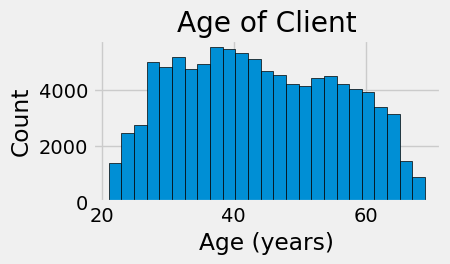

In [16]:
# Distribution de l'âge en années — train uniquement
if "DAYS_BIRTH" in app_train_raw.columns:
    plt.style.use("fivethirtyeight")
    plt.figure(figsize=(4, 2))
    plt.hist(app_train_raw["DAYS_BIRTH"].abs() / 365, edgecolor="k", bins=25)
    plt.title("Age of Client")
    plt.xlabel("Age (years)")
    plt.ylabel("Count")
    plt.show()

In [17]:
# Corrélations des variables EXT_SOURCE avec TARGET et DAYS_BIRTH
ext_cols = [col for col in ["TARGET", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "DAYS_BIRTH"] if col in app_train_raw.columns]
if len(ext_cols) >= 2:
    ext_data = app_train_raw[ext_cols].copy()
    if "DAYS_BIRTH" in ext_data.columns:
        ext_data["DAYS_BIRTH"] = ext_data["DAYS_BIRTH"].abs()
    ext_data_corrs = ext_data.corr()
    display(ext_data_corrs)

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.153105,-0.161656,-0.178742,-0.076839
EXT_SOURCE_1,-0.153105,1.000000,0.215801,0.185798,0.604018
EXT_SOURCE_2,-0.161656,0.215801,1.000000,0.108796,0.092396
EXT_SOURCE_3,-0.178742,0.185798,0.108796,1.000000,0.209851
DAYS_BIRTH,-0.076839,0.604018,0.092396,0.209851,1.000000


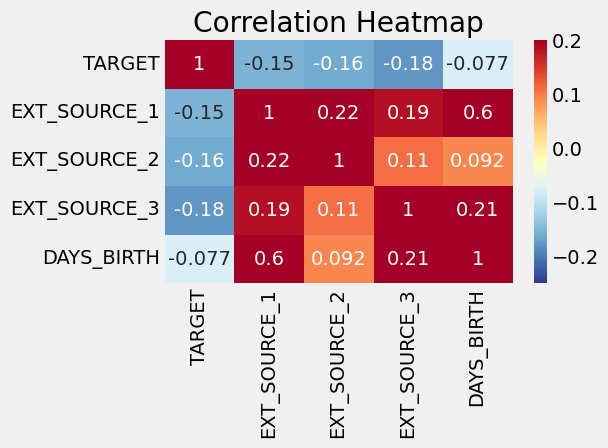

In [18]:
# Heatmap de corrélation EXT_SOURCE — équivalent au graphique initial
if "ext_data_corrs" in globals():
    plt.figure(figsize=(5, 3))
    sns.heatmap(ext_data_corrs, cmap=plt.cm.RdYlBu_r, vmin=-0.25, annot=True, vmax=0.2)
    plt.title("Correlation Heatmap")
    plt.show()

In [19]:
# Taux de valeurs manquantes — train uniquement
missing_train = app_train_raw.isna().mean().sort_values(ascending=False)
missing_train.head(20)

COMMONAREA_MEDI             0.697317
COMMONAREA_AVG              0.697317
COMMONAREA_MODE             0.697317
NONLIVINGAPARTMENTS_MODE    0.692747
NONLIVINGAPARTMENTS_AVG     0.692747
NONLIVINGAPARTMENTS_MEDI    0.692747
LIVINGAPARTMENTS_MODE       0.682647
LIVINGAPARTMENTS_AVG        0.682647
LIVINGAPARTMENTS_MEDI       0.682647
FONDKAPREMONT_MODE          0.682177
FLOORSMIN_AVG               0.677017
FLOORSMIN_MODE              0.677017
FLOORSMIN_MEDI              0.677017
YEARS_BUILD_MEDI            0.663457
YEARS_BUILD_MODE            0.663457
YEARS_BUILD_AVG             0.663457
OWN_CAR_AGE                 0.660197
LANDAREA_MEDI               0.592496
LANDAREA_MODE               0.592496
LANDAREA_AVG                0.592496
dtype: float64

## 3) Fonctions de feature engineering

Ces fonctions sont appliquées au train **et** au test.

Point important : `add_simple_features(df)` est appelée dans `make_features(df)`, donc elle s'applique aux deux datasets via :

```python
app_train_fe = make_features(app_train_raw)
app_test_fe = make_features(app_test_raw)
```

Elles ne doivent pas utiliser `TARGET` pour transformer les features. `TARGET` est seulement conservée dans le train.


In [20]:
def add_domain_features(df: pd.DataFrame) -> pd.DataFrame:
    """Feature engineering déterministe appliqué de la même façon au train et au test.

    Important : aucune statistique n'est apprise ici sur le test.
    """
    # df = df.copy()
    # Anomalie connue dans Home Credit : 365243 signifie généralement valeur manquante/anormale.
    if "DAYS_EMPLOYED" in df.columns:
        df["DAYS_EMPLOYED_ANOM"] = df["DAYS_EMPLOYED"].eq(365243)
        df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

    # Transformation déterministe : âge en jours positif.
    if "DAYS_BIRTH" in df.columns:
        df["DAYS_BIRTH"] = df["DAYS_BIRTH"].abs()

    return df

def add_simple_features(df: pd.DataFrame) -> pd.DataFrame:
    # Exemples simples, à compléter selon votre kernel
    # df = df.copy()
    if {"AMT_INCOME_TOTAL", "AMT_CREDIT"}.issubset(df.columns):
        df["RATIO_CREDIT_INCOME"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
    if {"AMT_ANNUITY", "AMT_CREDIT"}.issubset(df.columns):
        df["RATIO_ANNUITY_CREDIT"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]
    if {"DAYS_EMPLOYED", "DAYS_BIRTH"}.issubset(df.columns):
        df["RATIO_EMPLOYED_BIRTH"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]
    return df

def basic_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    inf_per_col = np.isinf(
        df.select_dtypes(include=np.number)
    ).sum()    
    inf_per_col = inf_per_col[inf_per_col > 0]
    print("Nombre d’infinis par colonne: ", inf_per_col.sort_values(ascending=False))    
    
    # Remplace inf par NaN, puis laisse la stratégie d'imputation au pipeline (ou fillna ici si vous préférez)
    # df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df
    
def make_features(df: pd.DataFrame) -> pd.DataFrame:
    """Pipeline FE commun train/test.

    Cette fonction centralise toutes les transformations à appliquer
    à la fois à application_train et application_test.
    """
    # df = df.copy()

    # 1. Règles métier déterministes
    df = add_domain_features(df)

    # 2. Features simples définies dans src.features
    # IMPORTANT : c'est ici que df_fe = add_simple_features(df) est appliqué.
    df = add_simple_features(df)

    # 3. Nettoyage générique projet
    df = basic_cleaning(df)
    
    return df


## 4) Appliquer le même FE au train et au test

In [21]:
app_train_fe = make_features(app_train_raw)
app_test_fe = make_features(app_test_raw)

print("Train FE shape:", app_train_fe.shape)
print("Test FE shape :", app_test_fe.shape)

app_train_fe.head()

Nombre d’infinis par colonne:  Series([], dtype: int64)
Nombre d’infinis par colonne:  Series([], dtype: int64)
Train FE shape: (99999, 126)
Test FE shape : (48744, 125)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_ANOM,RATIO_CREDIT_INCOME,RATIO_ANNUITY_CREDIT,RATIO_EMPLOYED_BIRTH
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,1.0,False,2.007889,0.060749,-0.067329
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,False,4.790750,0.027598,-0.070862
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,False,2.000000,0.050000,-0.011814
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,False,2.316167,0.094941,-0.159905
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,False,4.222222,0.042623,-0.152418


## 5) Contrôles de cohérence des colonnes

Le train a une colonne cible en plus. Les colonnes de features doivent être les mêmes entre train et test.

Si plus tard tu fais du `pd.get_dummies`, ce bloc réaligne aussi les colonnes pour éviter les différences de catégories.

In [22]:
# Séparation cible / features pour contrôler les colonnes
y_train_fe = app_train_fe[TARGET_COL].copy()
X_train_fe = app_train_fe.drop(columns=[TARGET_COL])

# Si par accident TARGET existe dans test, on l'enlève côté features
X_test_fe = app_test_fe.drop(columns=[TARGET_COL], errors="ignore")

# Réalignement de sécurité : mêmes colonnes et même ordre dans test que dans train
# Les éventuelles colonnes absentes dans test sont créées avec 0.
# Les colonnes en trop dans test sont ignorées.
X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=0)

# Reconstruction du train avec TARGET à la fin
app_train_fe = pd.concat([X_train_fe, y_train_fe], axis=1)
app_test_fe = X_test_fe.copy()

print("Train features:", X_train_fe.shape)
print("Test features :", app_test_fe.shape)
print("Same feature columns:", list(X_train_fe.columns) == list(app_test_fe.columns))

assert list(X_train_fe.columns) == list(app_test_fe.columns), "Train/test feature columns are not aligned"


Train features: (99999, 125)
Test features : (48744, 125)
Same feature columns: True


In [23]:
# Vérifications utiles
print("TARGET dans train_fe:", TARGET_COL in app_train_fe.columns)
print("TARGET dans test_fe :", TARGET_COL in app_test_fe.columns)

if "DAYS_EMPLOYED_ANOM" in app_train_fe.columns:
    print("DAYS_EMPLOYED_ANOM train:", app_train_fe["DAYS_EMPLOYED_ANOM"].sum())
    print("DAYS_EMPLOYED_ANOM test :", app_test_fe["DAYS_EMPLOYED_ANOM"].sum())

print("Train FE shape:", app_train_fe.shape)
print("Test FE shape :", app_test_fe.shape)

TARGET dans train_fe: True
TARGET dans test_fe : False
DAYS_EMPLOYED_ANOM train: 17865
DAYS_EMPLOYED_ANOM test : 9274
Train FE shape: (99999, 126)
Test FE shape : (48744, 125)


## 6) Sauvegarde

On sauvegarde deux fichiers séparés, prêts pour la modélisation :

- `train_fe.parquet` : features + `TARGET`
- `test_fe.parquet` : features uniquement

In [24]:
PATHS.data_processed.mkdir(parents=True, exist_ok=True)

out_train = PATHS.data_processed / "train_fe.parquet"
out_test = PATHS.data_processed / "test_fe.parquet"

save_parquet(app_train_fe, out_train)
save_parquet(app_test_fe, out_test)

print("Saved train FE to:", out_train)
print("Saved test FE to :", out_test)

Saved train FE to: C:\projects\openclassrooms_DS\P7\ds_project_7_credit_scoring\data\processed\train_fe.parquet
Saved test FE to : C:\projects\openclassrooms_DS\P7\ds_project_7_credit_scoring\data\processed\test_fe.parquet


## 7) Notes pour la suite modélisation

À partir de maintenant :

1. Charge `train_fe.parquet`.
2. Fais ton split interne `train_model / valid` à partir de ce train.
3. Utilise `train_model` pour GridSearchCV.
4. Utilise `valid` pour choisir le threshold.
5. Utilise `test_fe.parquet` seulement pour prédire / soumettre / évaluer si tu as les labels séparément.

